<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula10a_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processamento de Linguagem Natural

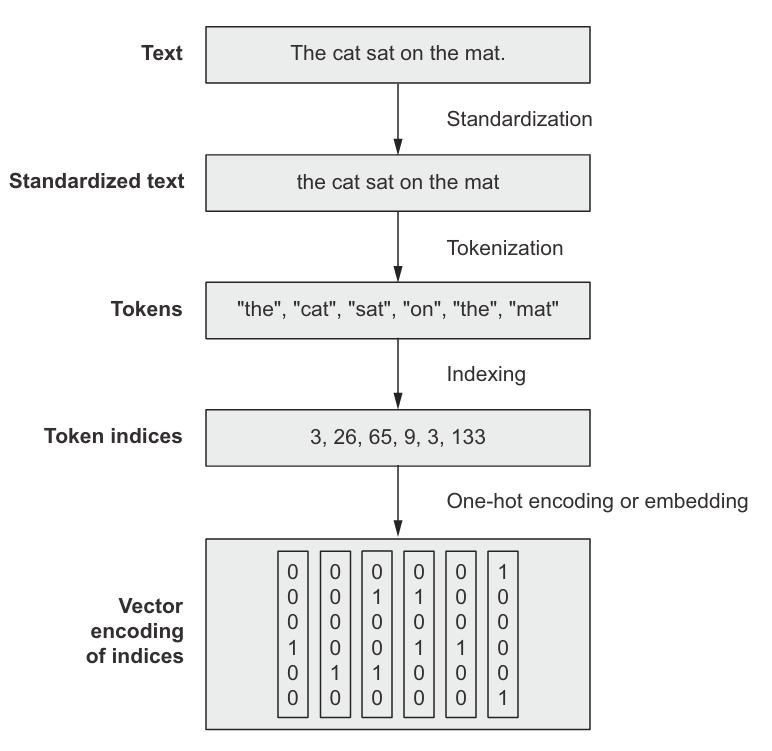

In [14]:
import tensorflow as tf
import re
import string

def standardize(input_data):
  lowercase = tf.strings.lower(input_data)
  std_txt = tf.strings.regex_replace(lowercase,
                                     '[%s]' % re.escape(string.punctuation),
                                     '')
  return std_txt

text = "The cat sat on the mat."
print(standardize(text).numpy())

b'the cat sat on the mat'


In [15]:
def tokenize(input_data):
  return tf.strings.split(input_data, ' ')

text = "The cat sat on the mat."
print(tokenize(standardize(text)).numpy())

[b'the' b'cat' b'sat' b'on' b'the' b'mat']


In [16]:
def get_dict_vocabulary(input_data):
  vocabulary = {}
  std_txt = standardize(input_data)
  split_txt = tokenize(std_txt)
  for word in split_txt:
    word = word.numpy().decode('utf-8')
    if word not in vocabulary:
      vocabulary[word] = len(vocabulary)
  return vocabulary

text = "The cat sat on the mat."
print(get_dict_vocabulary(text))

{'the': 0, 'cat': 1, 'sat': 2, 'on': 3, 'mat': 4}


In [18]:
import numpy as np

def get_one_hot_vocabulary(token, vocabulary):
  vector = np.zeros(len(vocabulary))
  index = vocabulary[token]
  vector[index] = 1
  return vector

text = "The cat sat on the mat."
vocabulary = get_dict_vocabulary(text)
print(get_one_hot_vocabulary('cat', vocabulary))

[0. 1. 0. 0. 0.]


In [19]:
get_one_hot_vocabulary('dog', vocabulary)

KeyError: 'dog'

In [33]:
import string

class Vectorizer():
  def standardize(self, text):
    lowercase = text.lower()
    std_txt = "".join(char for char in lowercase if char not in string.punctuation)
    return std_txt

  def tokenize(self, text):
    std_txt = self.standardize(text)
    return std_txt.split()

  def make_vocabulary(self, dataset):
    self.vocabulary = {"": 0, "[UNK]": 1}
    for text in dataset:
      tokens = self.tokenize(text)
      for token in tokens:
        if token not in self.vocabulary:
          self.vocabulary[token] = len(self.vocabulary)
    self.inverse_vocabulary = dict((v, k) for k, v in self.vocabulary.items())

  def encode(self, text):
    tokens = self.tokenize(text)
    return [self.vocabulary.get(token, 1) for token in tokens]

  def decode(self, tokens):
    return " ".join(self.inverse_vocabulary.get(token, "[UNK]") for token in tokens)

vectorizer = Vectorizer()
dataset = [
    "The cat sat on the mat.",
    "The dog sat on the rug.",
    "The cat sat on the rug mat."
]
vectorizer.make_vocabulary(dataset)
text = "The hamster sat on the floor."
encoded_sentence = vectorizer.encode(text)
print(encoded_sentence)
decoded_sentence = vectorizer.decode(encoded_sentence)
print(decoded_sentence)

[2, 1, 4, 5, 2, 1]
the [UNK] sat on the [UNK]


In [34]:
from tensorflow.keras.layers import TextVectorization
text_vectorization = TextVectorization(output_mode="int")
text_vectorization.adapt(dataset)
encoded_sentence = text_vectorization(text)
print(encoded_sentence)

tf.Tensor([2 1 3 4 2 1], shape=(6,), dtype=int64)


In [35]:
text_vectorization(dataset)

<tf.Tensor: shape=(3, 7), dtype=int64, numpy=
array([[2, 7, 3, 4, 2, 6, 0],
       [2, 8, 3, 4, 2, 5, 0],
       [2, 7, 3, 4, 2, 5, 6]])>

In [36]:
text_vectorization.get_vocabulary()

['',
 '[UNK]',
 np.str_('the'),
 np.str_('sat'),
 np.str_('on'),
 np.str_('rug'),
 np.str_('mat'),
 np.str_('cat'),
 np.str_('dog')]